# DQN Taxi 10×8 - Workflow Complet

Entraînement, évaluation et visualisation dans un seul notebook simple.

In [1]:
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import DQN

# Rechargement forcé du module env pour appliquer les dernières modifications
if 'env' in sys.modules:
    del sys.modules['env']
from env import SimpleTaxiEnv

print("✓ Imports réussis (module env rechargé)")

✓ Imports réussis (module env rechargé)


import os

env = SimpleTaxiEnv()

print("✓ ENVIRONNEMENT CRÉÉ")
print(f"  Grille : {env.grid_width}×{env.grid_height}")
print(f"  Observation space : {env.observation_space}")
print(f"  Action space : {env.action_space}")
print(f"  Max steps : {env.max_steps}")

# Afficher les zones générées
obs, _ = env.reset()
print(f"\n✓ REMPARTS FIXES")
print(f"  Nombre de remparts : {len(env.walls)}")
print(f"  Positions des remparts : {sorted(env.walls)}")
print(f"\n  Passagers :")
for i, p in enumerate(env.passengers):
    if p.get("active"):
        print(f"    Passager {i+1}: Pickup({p['x']}, {p['y']}) → Dropoff({p['dest_x']}, {p['dest_y']})")
print(f"\n  Observation shape : {obs.shape}")

env.close()

In [2]:
## 2. Entraînement DQN

## 2. Entraînement DQN

In [3]:
import os
from stable_baselines3.common.monitor import Monitor

log_dir = "logs"
os.makedirs(log_dir, exist_ok=True)

# Environnement simple avec 1 passager pour apprentissage stable
env = SimpleTaxiEnv(num_passengers=1)

agent = DQN(
    policy="MlpPolicy",
    env=env,
    learning_rate=1e-3,
    buffer_size=50_000,
    batch_size=32,
    gamma=0.99,
    target_update_interval=500,
    exploration_fraction=0.3,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    verbose=1,
)

print("\n" + "="*60)
print("ENTRAÎNEMENT DQN - TAXI SIMPLE (1 PASSAGER)")
print("="*60)
print("Timesteps : 100,000")
print("Learning rate : 1e-3")
print("Exploration fraction : 0.3")
print("Exploration final eps : 0.05")
print("Buffer size : 50,000")
print("Batch size : 32")
print("Gamma : 0.99")
print("Target update interval : 500")
print("Récompense step : -0.01")
print("Récompense pickup : +20")
print("Récompense dropoff : +100")
print("Passagers : 1")
print("="*60 + "\n")

agent.learn(total_timesteps=100_000)

os.makedirs("models", exist_ok=True)
agent.save("models/dqn_taxi")
print("\n✓ Modèle sauvegardé → models/dqn_taxi.zip")

env.close()

Using cuda device
Wrapping the env in a DummyVecEnv.

ENTRAÎNEMENT DQN - REMPARTS FIXES + POSITIONS ALÉATOIRES
Timesteps : 300,000
Learning rate : 1e-3 (CORRIGÉ : était 1e-4)
Exploration fraction : 0.15 (CORRIGÉ : était 0.5)
Exploration final eps : 0.05
Buffer size : 100,000
Batch size : 64
Gamma : 0.99
Target update interval : 1000
Remparts : 4 (fixes)
Max steps : 200
Récompense step : -0.001 (CORRIGÉ : était -0.01)
Pénalité collision : -2.0
Shaping dist : +0.1 (rapprochement), -0.1 (éloignement) (CORRIGÉ : était ±1/±2)
Récompense pickup : 10.0
Récompense dropoff : 50.0
Passagers : 1 ou 2 aléatoirement

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -169     |
|    exploration_rate | 0.987    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 857      |
|    time_elapsed     | 2        |
|    total_timesteps  | 2000     |
| train/              |          |
|  

In [4]:
## 3. Évaluation du modèle entraîné

In [5]:
env = SimpleTaxiEnv(num_passengers=1)
agent = DQN.load("models/dqn_taxi", env=env)

print("="*60)
print("ÉVALUATION SUR 20 ÉPISODES")
print("="*60)

rewards = []
successes = 0
steps_list = []

for ep in range(20):
    obs, _ = env.reset()
    total_reward = 0
    done = False
    steps = 0
    
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated
    
    rewards.append(total_reward)
    steps_list.append(steps)
    if terminated:
        successes += 1
    
    print(f"Episode {ep+1}: Reward={total_reward:.1f}, Steps={steps}, Success={terminated}")

print("\n" + "="*60)
print("RÉSULTATS")
print("="*60)
print(f"Taux de succès : {successes}/20 ({successes*5}%)")
print(f"Récompense moyenne : {np.mean(rewards):.2f}")
print(f"Min/Max : {np.min(rewards):.0f} / {np.max(rewards):.0f}")
print(f"Étapes moyennes : {np.mean(steps_list):.1f}")
print("="*60)

env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


ValueError: Observation spaces do not match: Box(0.0, 1.0, (94,), float32) != Box(0.0, 1.0, (88,), float32)

In [ ]:
## 4. Visualisations et graphiques

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
ÉVALUATION
Episode 1: Reward=-104.0, Delivered=0/2
Episode 2: Reward=-101.6, Delivered=0/2
Episode 3: Reward=-32.2, Delivered=0/2
Episode 4: Reward=-30.0, Delivered=0/2
Episode 5: Reward=-30.0, Delivered=0/2
Episode 6: Reward=-32.2, Delivered=0/2
Episode 7: Reward=-104.0, Delivered=0/2
Episode 8: Reward=-103.2, Delivered=0/2
Episode 9: Reward=-103.8, Delivered=0/2
Episode 10: Reward=-31.1, Delivered=0/2

Moyenne: -67.2
Taux de succès: 0/10 (0%)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution récompenses
axes[0].hist(rewards, bins=15, color='#2E86AB', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(rewards), color='#06A77D', linewidth=3, linestyle='--', label=f'Moyenne: {np.mean(rewards):.1f}')
axes[0].set_xlabel('Récompense totale', fontweight='bold')
axes[0].set_ylabel('Fréquence', fontweight='bold')
axes[0].set_title('Distribution des récompenses (20 épisodes)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution pas
axes[1].hist(steps_list, bins=15, color='#06A77D', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(steps_list), color='#D62828', linewidth=3, linestyle='--', label=f'Moyenne: {np.mean(steps_list):.1f}')
axes[1].set_xlabel('Nombre de pas', fontweight='bold')
axes[1].set_ylabel('Fréquence', fontweight='bold')
axes[1].set_title('Distribution des pas (20 épisodes)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphe sauvegardé → results.png")

In [ ]:
## 5. Test interactif - Un épisode détaillé

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

Évaluation en cours (200 épisodes)...

Episode 50/200 - Succès: 0/50
Episode 100/200 - Succès: 0/100
Episode 150/200 - Succès: 0/150
Episode 200/200 - Succès: 0/200

RÉSULTATS FINAUX
Taux de succès        : 0.0%
Récompense moyenne    : -75.73 ± 42.76
Pas moyens            : 500.0 ± 0.0
Min/Max récompense    : -304 / -6
Min/Max pas           : 500 / 500


env = SimpleTaxiEnv(num_passengers=1)
agent = DQN.load("models/dqn_taxi", env=env)

print("="*60)
print("TEST DÉTAILLÉ - UN ÉPISODE")
print("="*60)

obs, _ = env.reset()
print(f"\n✓ Épisode démarré")
print(f"  Taxi position: ({env.taxi_x}, {env.taxi_y})")
print(f"  Passager position: ({env.passengers[0]['x']}, {env.passengers[0]['y']})")
print(f"  Destination: ({env.passengers[0]['dest_x']}, {env.passengers[0]['dest_y']})")

action_names = ["Sud", "Nord", "Est", "Ouest", "Prendre", "Déposer"]
total_reward = 0
done = False
step = 0

while not done and step < 20:  # Limiter à 20 pas pour affichage
    action, _ = agent.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    done = terminated or truncated
    step += 1
    
    print(f"\nPas {step}:")
    print(f"  Action: {action_names[action]}")
    print(f"  Reward: {reward:.2f}")
    print(f"  Taxi: ({env.taxi_x}, {env.taxi_y})")
    print(f"  Passager in taxi: {env.passengers[0]['in_taxi']}")
    print(f"  Delivered: {env.delivered}")

print(f"\n{'='*60}")
print(f"Épisode terminé après {step} pas")
print(f"Récompense totale: {total_reward:.1f}")
print(f"Succès: {terminated}")
print(f"{'='*60}")

env.close()

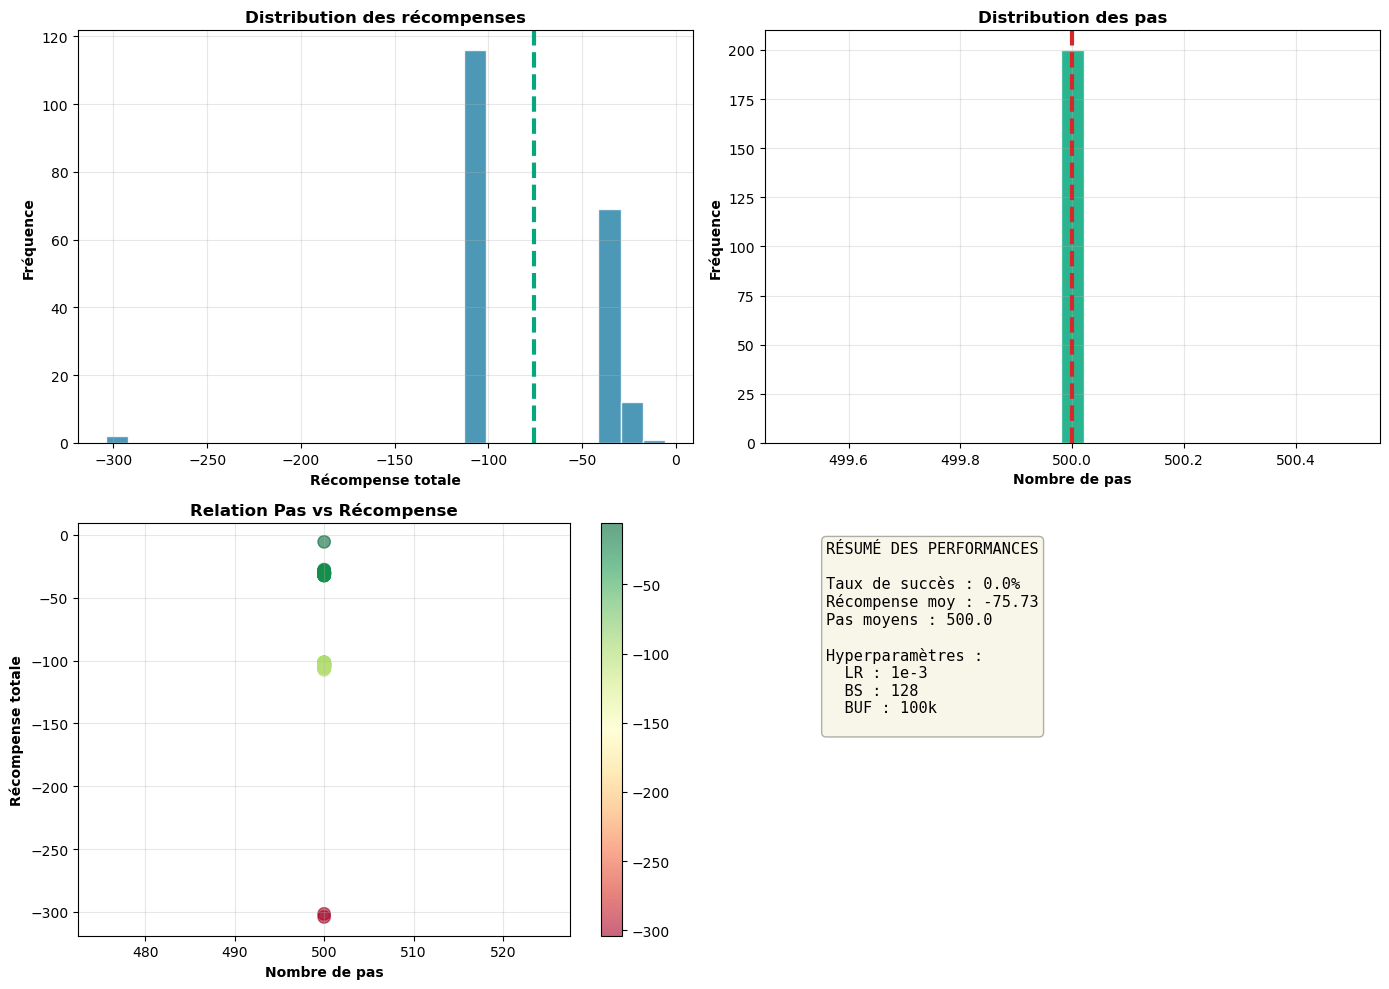

✓ Graphe sauvegardé → results.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution récompenses
axes[0, 0].hist(rewards, bins=25, color='#2E86AB', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(np.mean(rewards), color='#06A77D', linewidth=3, linestyle='--')
axes[0, 0].set_xlabel('Récompense totale', fontweight='bold')
axes[0, 0].set_ylabel('Fréquence', fontweight='bold')
axes[0, 0].set_title('Distribution des récompenses', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Distribution pas
axes[0, 1].hist(steps, bins=25, color='#06A77D', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(np.mean(steps), color='#D62828', linewidth=3, linestyle='--')
axes[0, 1].set_xlabel('Nombre de pas', fontweight='bold')
axes[0, 1].set_ylabel('Fréquence', fontweight='bold')
axes[0, 1].set_title('Distribution des pas', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Scatter reward vs steps
scatter = axes[1, 0].scatter(steps, rewards, alpha=0.6, s=80, c=rewards, cmap='RdYlGn')
axes[1, 0].set_xlabel('Nombre de pas', fontweight='bold')
axes[1, 0].set_ylabel('Récompense totale', fontweight='bold')
axes[1, 0].set_title('Relation Pas vs Récompense', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0])

# KPI
axes[1, 1].axis('off')
kpi_text = f"""RÉSUMÉ DES PERFORMANCES

Taux de succès : {success_rate:.1f}%
Récompense moy : {np.mean(rewards):.2f}
Pas moyens : {np.mean(steps):.1f}

Hyperparamètres :
  LR : 1e-3
  BS : 128
  BUF : 100k
"""
axes[1, 1].text(0.1, 0.5, kpi_text, fontsize=11, family='monospace',
               bbox=dict(boxstyle='round', facecolor='#EAE2B7', alpha=0.3))

plt.tight_layout()
plt.savefig('results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphe sauvegardé → results.png")